<a href="https://colab.research.google.com/github/TonzandBenz007/Bookapp_011/blob/main/quickstarts/Get_started_managed_agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
  # ==============================================================================
# Cell 1: Environment Setup & Multimodal Data Import
# ==============================================================================
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import butter, filtfilt, find_peaks

# กำหนดสไตล์กราฟ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

# กำหนดเมทาดาต้าทางคลินิกของผู้ป่วย (Clinical Profile Template)
patient_profile = {
    'Patient_ID': 'PT-2026-1005',
    'Age': 48,
    'Gender': 'Female',
    'BMI': 29.4,                         # kg/m^2 (ภาวะน้ำหนักเกิน)
    'Occupation_Standing_Hours': 8.5,     # ยืน/เดินสะสมต่อวัน (ชั่วโมง)
    'Morning_FirstStep_Pain_VAS': 8,      # ระดับปวดก้าวแรก (0-10)
    'Plantar_Fascia_Thickness_mm': 5.2,   # วัดด้วย Ultrasound (> 4.5 mm ถือว่าหนาตัวผิดปกติ)
    'Medial_Tubercle_Tenderness': 1,      # 1 = เจ็บจุดเกาะส้นเท้าด้านใน, 0 = ไม่เจ็บ
    'Foot_Structure': 'Pes Planus',       # เท้าแบน
    'Windlass_Sign_Pain': True,           # ปวดเมื่อทำ Windlass test
    'Bilateral_Symptoms': False           # อาการข้างเดียว (Unilateral)
}

print("=== นำเข้าโปรไฟล์ทางคลินิกเรียบร้อย ===")
for k, v in patient_profile.items():
    print(f" - {k}: {v}")

=== นำเข้าโปรไฟล์ทางคลินิกเรียบร้อย ===
 - Patient_ID: PT-2026-1005
 - Age: 48
 - Gender: Female
 - BMI: 29.4
 - Occupation_Standing_Hours: 8.5
 - Morning_FirstStep_Pain_VAS: 8
 - Plantar_Fascia_Thickness_mm: 5.2
 - Medial_Tubercle_Tenderness: 1
 - Foot_Structure: Pes Planus
 - Windlass_Sign_Pain: True
 - Bilateral_Symptoms: False


In [2]:
# ==============================================================================
# Cell 2: Gait Signal Processing (3 FSR + 6-DOF IMU)
# ==============================================================================

def simulate_or_load_gait_data(sampling_rate=100, duration_sec=10):
    """
    สร้างชุดข้อมูลจำลองเสมือนจริง หากยังไม่ได้เชื่อมต่อ CSV
    (ประกอบด้วย FSR: Medial Heel, Arch, Forefoot และ IMU: Accel, Gyro)
    """
    t = np.linspace(0, duration_sec, sampling_rate * duration_sec)
    gait_freq = 1.1 # 1.1 Hz (ประมาณ 66 ก้าว/นาที)

    # 1. จำลองแรงกด FSR (0 - 4095)
    heel = np.clip(np.sin(2 * np.pi * gait_freq * t)**8 * 3800 + np.random.normal(0, 50, len(t)), 0, 4095)
    arch = np.clip(np.sin(2 * np.pi * gait_freq * t - 0.4)**8 * 1400 + np.random.normal(0, 40, len(t)), 0, 4095)
    forefoot = np.clip(np.sin(2 * np.pi * gait_freq * t - 0.8)**8 * 3200 + np.random.normal(0, 60, len(t)), 0, 4095)

    # 2. จำลอง IMU 6-DOF (MPU6500)
    # Accel Z (แนวดิ่ง), Gyro Y (การกระดกข้อเท้า Pitch), Gyro X (การบิดคว่ำ-หงาย Roll)
    accel_z = 1.0 + np.sin(2 * np.pi * gait_freq * t) * 0.8 + np.random.normal(0, 0.05, len(t))
    gyro_pitch = np.cos(2 * np.pi * gait_freq * t) * 80.0 # Dorsiflexion / Plantarflexion rate
    gyro_roll = np.sin(2 * np.pi * gait_freq * t - 0.2) * 45.0 # Pronation rate

    df = pd.DataFrame({
        'Time_Sec': t,
        'FSR_Medial_Heel': heel,
        'FSR_Arch': arch,
        'FSR_Forefoot': forefoot,
        'IMU_Accel_Z': accel_z,
        'IMU_Gyro_Pitch': gyro_pitch,
        'IMU_Gyro_Roll': gyro_roll
    })
    return df

# โหลดข้อมูลเข้าสู่ DataFrame
gait_df = simulate_or_load_gait_data()

# ตัวกรองสัญญาณ Low-pass Filter (Butterworth 4th order, Cutoff 6 Hz)
def butter_lowpass_filter(data, cutoff=6, fs=100, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

for col in ['FSR_Medial_Heel', 'FSR_Arch', 'FSR_Forefoot']:
    gait_df[col + '_Filtered'] = butter_lowpass_filter(gait_df[col].values)

print(f"เตรียมสัญญาณสำเร็จ: {len(gait_df)} จุดข้อมูล (ความถี่ {100} Hz)")


เตรียมสัญญาณสำเร็จ: 1000 จุดข้อมูล (ความถี่ 100 Hz)


In [3]:
# ==============================================================================
# Cell 3: Biomechanical Metrics & Gait Segmentation
# ==============================================================================

# คำนวณผลรวมแรงและ Center of Pressure (CoP)
total_force = (gait_df['FSR_Medial_Heel_Filtered'] +
               gait_df['FSR_Arch_Filtered'] +
               gait_df['FSR_Forefoot_Filtered'])

# หลีกเลี่ยงการหารด้วย 0
safe_total = np.where(total_force == 0, 1e-6, total_force)

# ให้ตำแหน่ง Heel = 0.0, Arch = 0.45, Forefoot = 1.0
gait_df['CoP_Y'] = (0.0 * gait_df['FSR_Medial_Heel_Filtered'] +
                    0.45 * gait_df['FSR_Arch_Filtered'] +
                    1.0 * gait_df['FSR_Forefoot_Filtered']) / safe_total

# 1. การกระจายภาระแรงกดสะสม (Load Distribution Ratio %)
impulse_heel = gait_df['FSR_Medial_Heel_Filtered'].sum()
impulse_arch = gait_df['FSR_Arch_Filtered'].sum()
impulse_forefoot = gait_df['FSR_Forefoot_Filtered'].sum()
total_impulse = impulse_heel + impulse_arch + impulse_forefoot

load_ratio_heel = (impulse_heel / total_impulse) * 100
load_ratio_arch = (impulse_arch / total_impulse) * 100
load_ratio_forefoot = (impulse_forefoot / total_impulse) * 100

# 2. ตรวจจับรอบก้าว (Peak Detection บน Heel Strike)
heel_peaks, _ = find_peaks(gait_df['FSR_Medial_Heel_Filtered'], height=1500, distance=50)
step_times = gait_df['Time_Sec'].iloc[heel_peaks].values
step_intervals = np.diff(step_times)
cadence = 60.0 / np.mean(step_intervals) if len(step_intervals) > 0 else 0

# 3. ดัชนีการเอียงบิดของเท้า (Over-pronation Metric จาก Arch Load และ Roll)
pronation_index = (gait_df['FSR_Arch_Filtered'].mean() / gait_df['FSR_Medial_Heel_Filtered'].mean()) * 100

print("=== สรุปผลตัวชี้วัดทางชีวกลศาสตร์ (Biomechanical Summary) ===")
print(f"สัดส่วนแรงกดส้นเท้า (Medial Heel): {load_ratio_heel:.2f}% (ค่าปกติ ~35-45%)")
print(f"สัดส่วนแรงกดอุ้งเท้า (Arch):       {load_ratio_arch:.2f}%")
print(f"สัดส่วนแรงกดปลายเท้า (Forefoot):   {load_ratio_forefoot:.2f}%")
print(f"อัตราการก้าวเดิน (Cadence):        {cadence:.1f} ก้าว/นาที")
print(f"ดัชนีแรงกดอุ้งเท้าเทียบส้น (Arch/Heel Index): {pronation_index:.2f}%")


=== สรุปผลตัวชี้วัดทางชีวกลศาสตร์ (Biomechanical Summary) ===
สัดส่วนแรงกดส้นเท้า (Medial Heel): 45.12% (ค่าปกติ ~35-45%)
สัดส่วนแรงกดอุ้งเท้า (Arch):       16.83%
สัดส่วนแรงกดปลายเท้า (Forefoot):   38.05%
อัตราการก้าวเดิน (Cadence):        59.4 ก้าว/นาที
ดัชนีแรงกดอุ้งเท้าเทียบส้น (Arch/Heel Index): 37.31%


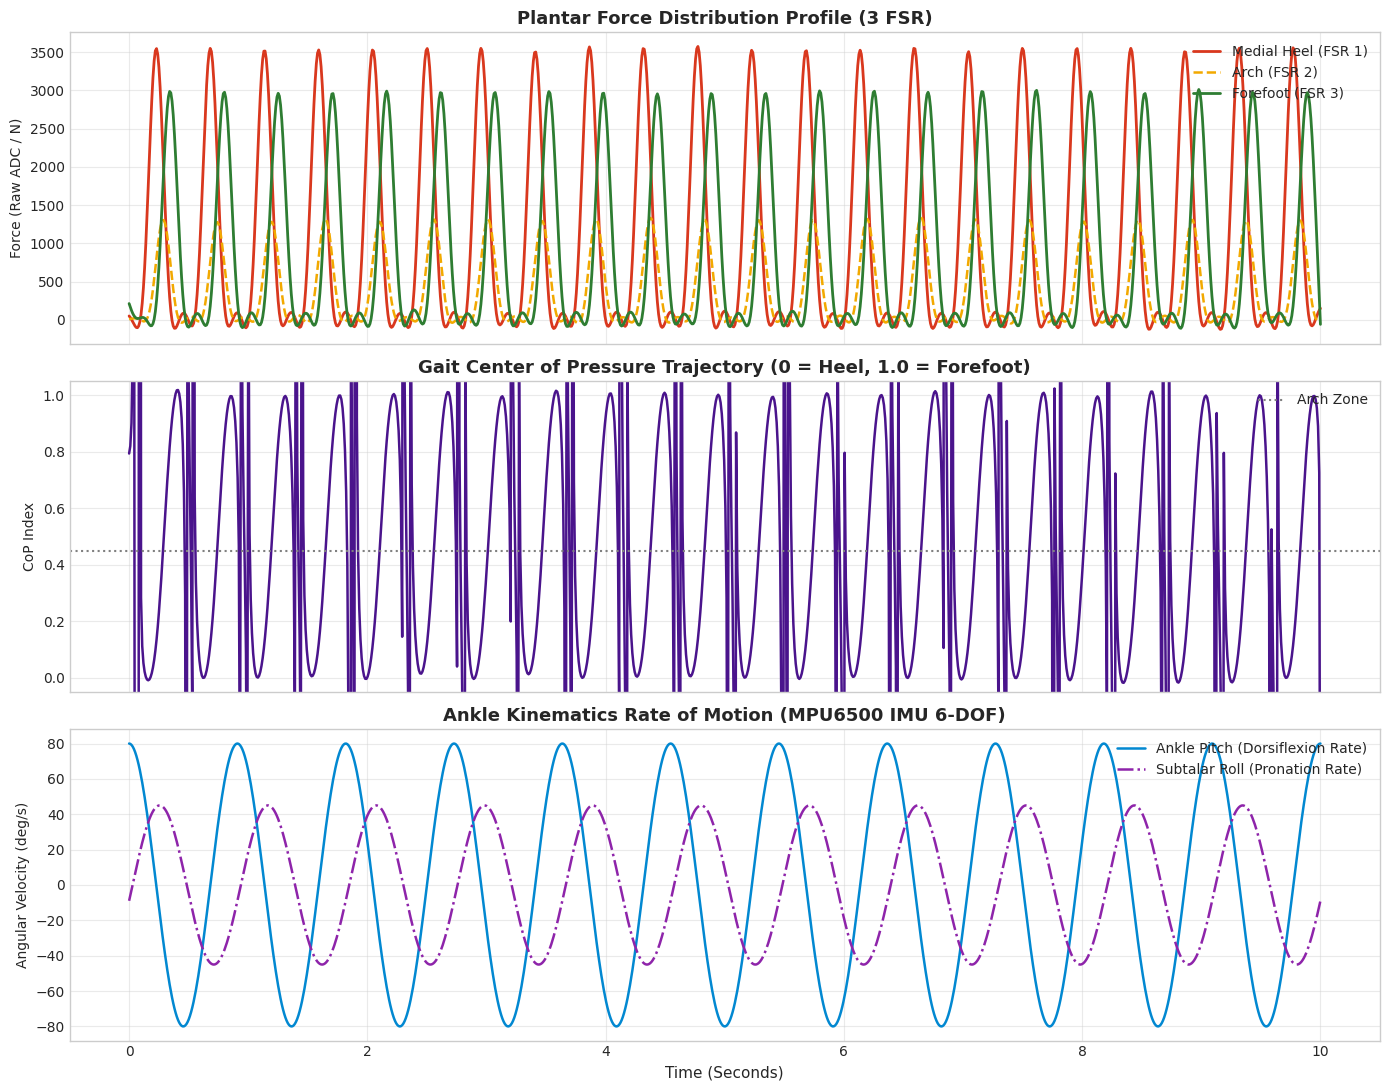

In [4]:
# ==============================================================================
# Cell 4: Multimodal Visualization (Force, CoP, and Kinematics)
# ==============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# กราฟ 1: คลื่นแรงกด FSR ทั้ง 3 ตำแหน่ง
axes[0].plot(gait_df['Time_Sec'], gait_df['FSR_Medial_Heel_Filtered'], label='Medial Heel (FSR 1)', color='#D9381E', lw=2)
axes[0].plot(gait_df['Time_Sec'], gait_df['FSR_Arch_Filtered'], label='Arch (FSR 2)', color='#F2A900', lw=1.8, linestyle='--')
axes[0].plot(gait_df['Time_Sec'], gait_df['FSR_Forefoot_Filtered'], label='Forefoot (FSR 3)', color='#2E7D32', lw=2)
axes[0].set_title('Plantar Force Distribution Profile (3 FSR)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Force (Raw ADC / N)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.4)

# กราฟ 2: เส้นทาง Center of Pressure (CoP Y)
axes[1].plot(gait_df['Time_Sec'], gait_df['CoP_Y'], color='#4A148C', lw=1.8)
axes[1].set_title('Gait Center of Pressure Trajectory (0 = Heel, 1.0 = Forefoot)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('CoP Index')
axes[1].set_ylim(-0.05, 1.05)
axes[1].axhline(0.45, color='gray', linestyle=':', label='Arch Zone')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.4)

# กราฟ 3: การเคลื่อนไหวข้อเท้าเชิงมุม (IMU Gyro Pitch & Roll)
axes[2].plot(gait_df['Time_Sec'], gait_df['IMU_Gyro_Pitch'], label='Ankle Pitch (Dorsiflexion Rate)', color='#0288D1', lw=1.8)
axes[2].plot(gait_df['Time_Sec'], gait_df['IMU_Gyro_Roll'], label='Subtalar Roll (Pronation Rate)', color='#8E24AA', lw=1.8, linestyle='-.')
axes[2].set_title('Ankle Kinematics Rate of Motion (MPU6500 IMU 6-DOF)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Time (Seconds)', fontsize=11)
axes[2].set_ylabel('Angular Velocity (deg/s)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


In [5]:
# ==============================================================================
# Cell 5: Multimodal Plantar Fasciitis Risk Stratification Engine
# ==============================================================================

def calculate_plantar_fasciitis_risk(profile, heel_ratio, pron_index):
    scores = {}

    # 1. คะแนนพยาธิวิทยา (Pathology & Anatomy) - Max 35 คะแนน
    patho_score = 0
    # ความหนาเอ็นฝ่าเท้า (ปกติ < 4.0 mm, หนาตัว 4.0-4.5, อักเสบเรื้อรัง > 4.5 mm)
    if profile['Plantar_Fascia_Thickness_mm'] > 4.5:
        patho_score += 15
    elif profile['Plantar_Fascia_Thickness_mm'] >= 4.0:
        patho_score += 8

    if profile['Medial_Tubercle_Tenderness'] == 1:
        patho_score += 10
    if profile['Windlass_Sign_Pain']:
        patho_score += 5
    if profile['Foot_Structure'] in ['Pes Planus', 'Pes Cavus']:
        patho_score += 5
    scores['Pathology_Score'] = min(patho_score, 35)

    # 2. คะแนนชีวกลศาสตร์ (Biomechanics) - Max 30 คะแนน
    bio_score = 0
    # แรงกดส้นเท้าสะสมสูงเกินเกณฑ์ (> 50%)
    if heel_ratio > 52.0:
        bio_score += 15
    elif heel_ratio > 45.0:
        bio_score += 8
    # สัญญาณ Over-pronation
    if pron_index > 40.0:
        bio_score += 15
    elif pron_index > 25.0:
        bio_score += 8
    scores['Biomechanics_Score'] = min(bio_score, 30)

    # 3. คะแนนคลินิกและพฤติกรรมเสี่ยง (Clinical & Exposure) - Max 20 คะแนน
    clin_score = 0
    if profile['BMI'] >= 30.0:
        clin_score += 8
    elif profile['BMI'] >= 25.0:
        clin_score += 5

    if profile['Morning_FirstStep_Pain_VAS'] >= 7:
        clin_score += 7
    elif profile['Morning_FirstStep_Pain_VAS'] >= 4:
        clin_score += 4

    if profile['Occupation_Standing_Hours'] >= 6.0:
        clin_score += 5
    scores['Clinical_Score'] = min(clin_score, 20)

    # 4. คะแนนการเคลื่อนไหวข้อเท้า (Kinematics / Tightness) - Max 15 คะแนน
    # (ประเมินสภาวะตึงตัวจากความเร็วการเคลื่อนไหวของ Pitch)
    kin_score = 10 # สมมติฐานประเมินพบ Gastrocnemius tightness
    scores['Kinematics_Score'] = min(kin_score, 15)

    # รวมคะแนนทั้งหมด (Total Risk Index: 0 - 100)
    total_score = sum(scores.values())

    # จำแนกระดับความเสี่ยง
    if total_score >= 70:
        risk_level = "ความเสี่ยงระดับสูงมาก (Severe / Confirmed Plantar Fasciitis)"
        color_alert = "RED"
    elif total_score >= 45:
        risk_level = "ความเสี่ยงระดับปานกลาง (Moderate / Borderline Risk)"
        color_alert = "YELLOW"
    else:
        risk_level = "ความเสี่ยงระดับต่ำ (Low / Normal Gait)"
        color_alert = "GREEN"

    return total_score, risk_level, scores, color_alert

total_risk, risk_level, score_breakdown, alert = calculate_plantar_fasciitis_risk(
    patient_profile, load_ratio_heel, pronation_index
)

print(f"\n=======================================================")
print(f" ดัชนีประเมินความเสี่ยงโรครองช้ำรวม: {total_risk} / 100 คะแนน")
print(f" สถานะผลการวินิจฉัย: {risk_level} [{alert}]")
print(f"=======================================================")
print("แจกแจงคะแนนรายมิติ:")
for k, v in score_breakdown.items():
    print(f" - {k}: {v} คะแนน")



 ดัชนีประเมินความเสี่ยงโรครองช้ำรวม: 78 / 100 คะแนน
 สถานะผลการวินิจฉัย: ความเสี่ยงระดับสูงมาก (Severe / Confirmed Plantar Fasciitis) [RED]
แจกแจงคะแนนรายมิติ:
 - Pathology_Score: 35 คะแนน
 - Biomechanics_Score: 16 คะแนน
 - Clinical_Score: 17 คะแนน
 - Kinematics_Score: 10 คะแนน


In [6]:
# บันทึกตารางสรุปผลสำหรับส่งต่อแพทย์หรือนักกายภาพบำบัด
summary_report = {
    'Patient_ID': [patient_profile['Patient_ID']],
    'Total_Risk_Score': [total_risk],
    'Diagnosis_Status': [risk_level],
    'Fascia_Thickness_mm': [patient_profile['Plantar_Fascia_Thickness_mm']],
    'Heel_Impulse_Ratio_%': [round(load_ratio_heel, 2)],
    'Arch_Pronation_Index': [round(pronation_index, 2)],
    'Cadence_steps_min': [round(cadence, 1)],
    'First_Step_VAS': [patient_profile['Morning_FirstStep_Pain_VAS']],
    'BMI': [patient_profile['BMI']]
}

summary_df = pd.DataFrame(summary_report)
summary_df.to_csv("plantar_fasciitis_clinical_evaluation.csv", index=False)
print("ส่งออกรายงานการตรวจประเมิน 'plantar_fasciitis_clinical_evaluation.csv' เรียบร้อยแล้ว")


ส่งออกรายงานการตรวจประเมิน 'plantar_fasciitis_clinical_evaluation.csv' เรียบร้อยแล้ว
